#### To perform Data Cleaning and Regularization Operation on Algerian Forest Fire Dataset


##### Step 1:   Import all the necessary libraries

In [2410]:
import  numpy             as  np
import  pandas            as  pd
import  matplotlib.pyplot as plt
import  seaborn           as sns

from    sklearn.model_selection import  train_test_split, GridSearchCV, KFold, cross_val_score
from    sklearn.preprocessing   import  StandardScaler, PolynomialFeatures
from    sklearn.pipeline        import  Pipeline
from    sklearn.linear_model    import  LinearRegression, Ridge, Lasso, ElasticNet
from    sklearn.metrics         import  mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

#### Step 2: Load the Dataset

In [2411]:
df = pd.read_csv("Algerian_forest_fires_dataset_UPDATE.csv")

In [2412]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


#### OBSERVATIONS:

1.  The above dataset explains about the forest fire dataset where each and every record explains about the forest fire data.

2.  The independent features are 

     (a.)   day

     (b.)   month

     (c.)   year

     (d.)   Temperature

     (e.)   RH

     (f.)   Ws

     (g.)   Rain

     (h.)   FFMC

     (i.)   DMC

     (j.)   DC

     (k.)   ISI

     (l.)   BUI

     (m.)   Classes


3.  The dependent feature in the dataset is "FWI". It stands for Fire Weather Index.

4.  The main aim of the project is to predict the FWI (Fire Weather Index) for the forest fire dataset.

#### Step 3:    Perform the Data Exploration

In [2413]:
#### To remove the spaces from the columns

df.columns = df.columns.str.strip()

In [2414]:
#### get the top five records used in the dataset

df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [2415]:
#### get the bottom five records in the dataset

df.tail()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
241,26,09,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire
242,27,09,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire
243,28,09,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire
244,29,09,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire
245,30,09,2012,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,not fire


In [2416]:
#### get the total length of the records used in the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 246


In [2417]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (246, 14)


In [2418]:
#### get the columns used in the dataset

df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes'],
      dtype='object')

In [2419]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4   RH           245 non-null    object
 5   Ws           245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.0+ KB


In [2420]:
#### get the descriptive statistical summary about the columns in the dataset

df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
count,246,245,245,245,245,245,245,245,245,245,245,245,245,244
unique,33,5,2,20,63,19,40,174,167,199,107,175,128,9
top,01,07,2012,35,55,14,0,88.9,7.9,8,1.1,3,0.4,fire
freq,8,62,244,29,10,43,133,8,5,5,8,5,12,131


#### Step 4:    Perform Data Cleaning and Feature Engineering

In [2421]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [2422]:
### get the unique counts of the days

df['day'].value_counts()

day
01                               8
02                               8
03                               8
04                               8
05                               8
06                               8
07                               8
08                               8
09                               8
10                               8
11                               8
12                               8
13                               8
14                               8
15                               8
16                               8
17                               8
18                               8
19                               8
20                               8
21                               8
22                               8
23                               8
24                               8
25                               8
26                               8
27                               8
28                               8
29              

In [2423]:
df[df['day'] == 'Sidi-Bel Abbes Region Dataset']

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2424]:
df[df['day'] == 'day']

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
123,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes


In [2425]:
### Remove the record with day value as "Sidi-Bel Abbes Region Dataset" and "day" from the dataset

df = df.drop(122)

df = df.reset_index(drop=True)

In [2426]:
df[df['day'] == "day"]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes


In [2427]:
df = df.drop(122)

df = df.reset_index(drop=True)

In [2428]:
### get the unique counts of the days

df['day'].value_counts()

day
01    8
02    8
03    8
04    8
05    8
06    8
07    8
08    8
09    8
10    8
11    8
12    8
13    8
14    8
15    8
16    8
17    8
18    8
19    8
20    8
21    8
22    8
23    8
24    8
25    8
26    8
27    8
28    8
29    8
30    8
31    4
Name: count, dtype: int64

In [2429]:
df['month'].value_counts()

month
07    62
08    62
06    60
09    60
Name: count, dtype: int64

In [2430]:
df['year'].value_counts()

year
2012    244
Name: count, dtype: int64

In [2431]:
df['Temperature'].value_counts()

Temperature
35    29
31    25
34    24
33    23
30    22
36    21
32    21
29    18
28    15
37     9
27     8
39     6
25     6
26     5
24     3
40     3
38     3
22     2
42     1
Name: count, dtype: int64

In [2432]:
#### Convert all the 'day','month','year','Temperature',' RH',' Ws' into int type

x = ['day','month','year','Temperature','RH','Ws']

for a in x:
    df[a] = df[a].astype('int')

In [2433]:
#### Convert all the 'Rain','FFMC','DMC',' ISI',' BUI' into float type

x = ['Rain','FFMC','DMC','ISI','BUI']

for a in x:
    df[a] = df[a].astype('float')

In [2434]:
df['DC'] = pd.to_numeric(df['DC'], errors='coerce')

In [2435]:
df['FWI'] = pd.to_numeric(df['FWI'], errors='coerce')

In [2436]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          244 non-null    int64  
 1   month        244 non-null    int64  
 2   year         244 non-null    int64  
 3   Temperature  244 non-null    int64  
 4   RH           244 non-null    int64  
 5   Ws           244 non-null    int64  
 6   Rain         244 non-null    float64
 7   FFMC         244 non-null    float64
 8   DMC          244 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          244 non-null    float64
 11  BUI          244 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
dtypes: float64(7), int64(6), object(1)
memory usage: 26.8+ KB


#### OBSERVATIONS:

1.  All the columns have been converted into their respective data types.

In [2437]:
#### To check for NULL records in the dataset

df.isnull().sum()

day            0
month          0
year           0
Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
DC             1
ISI            0
BUI            0
FWI            1
Classes        1
dtype: int64

#### OBSERVATIONS:

1.  'DC',   'FWI',  'Classes' are the columns that has one NULL record in the dataset.

In [2438]:
df[df['DC'].isnull()]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
165,14,7,2012,37,37,18,0.2,88.9,12.9,NaN,12.5,10.4,NaN,NaN


In [2439]:
#### Replace the 'DC' value with the mean 

df['DC'] = df['DC'].fillna(df['DC'].mean())

In [2440]:
#### Replace the 'FWI' value with the mean 

df['FWI'] = df['FWI'].fillna(df['FWI'].mean())

In [2441]:
df['Classes'].value_counts()


df['Classes'] = np.where(df['Classes'].str.contains("not fire"),0,1)

In [2442]:
#### To again check for NULL records in the dataset

df.isnull().sum()

day            0
month          0
year           0
Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [2443]:
#### To check for any duplicate records in the dataset

df[df.duplicated()]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

In [2444]:
#### To find out the correlation between all the columns in the dataset

df.corr()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
day,1.000000e+00,2.232788e-17,NaN,0.095772,-0.074209,0.047001,-0.112265,0.224032,0.491571,0.527909,0.177727,0.517229,0.350752,0.203216
month,2.232788e-17,1.000000e+00,NaN,-0.059017,-0.037884,-0.041447,0.035322,0.015577,0.068178,0.126458,0.061680,0.085822,0.082604,0.026027
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Temperature,9.577222e-02,-5.901677e-02,NaN,1.000000,-0.654443,-0.278132,-0.326786,0.677491,0.483105,0.374909,0.607551,0.455504,0.564599,0.506575
RH,-7.420934e-02,-3.788419e-02,NaN,-0.654443,1.000000,0.236084,0.222968,-0.645658,-0.405133,-0.225621,-0.690637,-0.348587,-0.577577,-0.420695
Ws,4.700086e-02,-4.144673e-02,NaN,-0.278132,0.236084,1.000000,0.170169,-0.163255,-0.001246,0.079005,0.015248,0.029756,0.032315,-0.073810
Rain,-1.122654e-01,3.532207e-02,NaN,-0.326786,0.222968,0.170169,1.000000,-0.544045,-0.288548,-0.297975,-0.347105,-0.299171,-0.324369,-0.376727
FFMC,2.240321e-01,1.557668e-02,NaN,0.677491,-0.645658,-0.163255,-0.544045,1.000000,0.602391,0.506778,0.739730,0.589652,0.690289,0.762942
DMC,4.915710e-01,6.817778e-02,NaN,0.483105,-0.405133,-0.001246,-0.288548,0.602391,1.000000,0.875887,0.674499,0.982073,0.875827,0.584757
DC,5.279093e-01,1.264583e-01,NaN,0.374909,-0.225621,0.079005,-0.297975,0.506778,0.875887,1.000000,0.505032,0.941610,0.739521,0.509775


<Axes: >

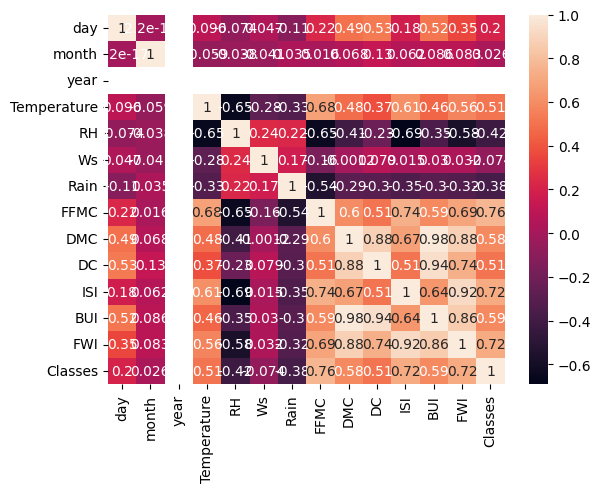

In [2445]:
#### To get the graphical representation between all the columns used in the dataset

sns.heatmap(df.corr(), annot=True)

In [2446]:
#### Remove the day, month and year column from the dataset

df.drop(columns=['day','month','year'],axis=1,inplace=True)

In [2447]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0


#### OBSERVATIONS:

1.  The dataset contains the independent features after performing data cleaning. They are as follows:---

     (a.)   Temperature

     (b.)   RH

     (c.)   Ws

     (d.)   Rain

     (e.)   FFMC

     (f.)   DMC

     (g.)   DC

     (h.)   ISI

     (i.)   BUI

     (j.)   Classes


2.  The dependent feature used in the dataset is FWI (Fire Weather Index).  

In [2448]:
#### Again check if there are any NULL record

df.isnull().sum()

Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [2449]:
#### Again check for the duplicate records in the dataset

df[df.duplicated()]

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

#### Step 5: Divide the dataset into independent and dependent features

In [2450]:
#### independent features

X = df.drop(columns = 'FWI',axis=1)

print(X)

     Temperature  RH  Ws  Rain  FFMC   DMC    DC  ISI   BUI  Classes
0             29  57  18   0.0  65.7   3.4   7.6  1.3   3.4        0
1             29  61  13   1.3  64.4   4.1   7.6  1.0   3.9        0
2             26  82  22  13.1  47.1   2.5   7.1  0.3   2.7        0
3             25  89  13   2.5  28.6   1.3   6.9  0.0   1.7        0
4             27  77  16   0.0  64.8   3.0  14.2  1.2   3.9        0
..           ...  ..  ..   ...   ...   ...   ...  ...   ...      ...
239           30  65  14   0.0  85.4  16.0  44.5  4.5  16.9        1
240           28  87  15   4.4  41.1   6.5   8.0  0.1   6.2        0
241           27  87  29   0.5  45.9   3.5   7.9  0.4   3.4        0
242           24  54  18   0.1  79.7   4.3  15.2  1.7   5.1        0
243           24  64  15   0.2  67.3   3.8  16.5  1.2   4.8        0

[244 rows x 10 columns]


In [2451]:
#### dependent features

Y = df['FWI']

print(Y)

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
239    6.5
240    0.0
241    0.2
242    0.7
243    0.5
Name: FWI, Length: 244, dtype: float64


#### Step 6: Divide the independent and dependent features into training and testing data

In [2452]:
from sklearn.model_selection  import  train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [2453]:
X_train

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes
228,32,51,13,0.0,88.7,16.0,50.2,6.9,17.8,1
208,33,37,16,0.0,92.2,61.3,167.2,13.1,64.0,1
96,29,75,16,0.0,80.8,3.4,24.0,2.8,5.1,1
167,31,83,17,0.0,84.5,19.4,33.1,4.7,19.2,1
84,34,64,14,0.0,88.9,40.5,171.3,9.0,50.9,1
...,...,...,...,...,...,...,...,...,...,...
106,24,82,15,0.4,44.9,0.9,7.3,0.2,1.4,0
14,28,80,17,3.1,49.4,3.0,7.4,0.4,3.0,0
92,25,76,17,7.2,46.0,1.3,7.5,0.2,1.8,0
179,33,57,16,0.0,87.5,15.7,37.6,6.7,15.7,1


In [2454]:
X_test

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes
24,31,64,15,0.0,86.7,14.2,63.8,5.7,18.3,1
6,33,54,13,0.0,88.2,9.9,30.5,6.4,10.9,1
153,33,48,16,0.0,87.6,7.9,17.8,6.8,7.8,1
211,35,53,17,0.5,80.2,20.7,149.2,2.7,30.6,1
198,40,41,10,0.1,92.0,22.6,65.1,9.5,24.2,1
176,39,64,9,1.2,73.8,11.7,15.9,1.1,11.4,0
192,39,39,15,0.2,89.3,15.8,35.4,8.2,15.8,1
124,29,80,14,2.0,48.7,2.2,7.6,0.3,2.6,0
9,28,79,12,0.0,73.2,9.5,46.3,1.3,12.6,0
101,33,73,12,1.8,59.9,2.2,8.9,0.7,2.7,0


In [2455]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (195, 10)
Shape of the input testing  data is: (49, 10)


In [2456]:
Y_train

228     9.8
208    30.3
96      1.7
167     7.3
84     20.9
       ... 
106     0.0
14      0.1
92      0.1
179     9.0
102     0.3
Name: FWI, Length: 195, dtype: float64

In [2457]:
Y_test

24      8.4
6       7.2
153     6.4
211     5.9
198    14.8
176     0.7
192    10.7
124     0.1
9       0.9
101     0.3
45      0.4
233     3.8
117     1.7
177     1.0
82     20.4
146     6.7
200    26.3
15      0.0
66      6.8
142     4.9
33      1.7
19      0.4
109     7.7
30      0.4
186    20.9
120     0.1
10      5.6
73     10.2
159     3.0
156    15.0
112     8.3
218     0.4
25     10.6
60     15.7
18      1.4
119     0.9
97      0.9
197     5.5
139     0.4
241     0.2
75      6.3
127     3.1
113     2.8
16      0.0
196    15.7
67      8.0
168     7.7
38      0.6
195    10.5
Name: FWI, dtype: float64

In [2458]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (195,)
Shape of the output testing  data is: (49,)


#### Step 8: Perform Hyper Parameter Tuning using GridSearchCV

In [2459]:
from  sklearn.pipeline  import  Pipeline

#### create an object for Pipeline

pipeline = Pipeline([
    ("sc"        ,   StandardScaler()        )             ,
    ("ridge"     ,   Ridge(alpha=0.1)        )
])

In [2460]:
#### create the parameter list

param_grid = {
    'ridge__alpha'      :      [0.01,   0.1,    1,  10, 100]
}

In [2461]:
#### perform the cross validation 

cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [2462]:
#### create the object of GridSearchCV

grid = GridSearchCV(
    pipeline                                            ,
    param_grid          =          param_grid           ,
    cv                  =           cv                  ,
    scoring             =           'r2'                
)

In [2463]:
#### Train the grid serach cv model

grid.fit(X_train, Y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('sc', StandardScaler()),
                                       ('ridge', Ridge(alpha=0.1))]),
             param_grid={'ridge__alpha': [0.01, 0.1, 1, 10, 100]},
             scoring='r2')

In [2464]:
#### Find out the best parameters and estimators from the GridSearchCV Model

best_parameters = grid.best_params_

print("Best Parameters of the model is:", best_parameters)

Best Parameters of the model is: {'ridge__alpha': 0.1}


In [2465]:
best_estimator = grid.best_estimator_

print("Best Estimator of the model is:", best_estimator)

Best Estimator of the model is: Pipeline(steps=[('sc', StandardScaler()), ('ridge', Ridge(alpha=0.1))])


In [2466]:
#### To perform the cross validation on the best estimator

cross_val_scores = cross_val_score(
    best_estimator                             ,
    X_train                                    ,
    Y_train                                    ,
    cv      =            cv                    ,
    scoring =            'r2' 
)

In [2467]:
print("Cross Validation Scores are:", cross_val_scores)

Cross Validation Scores are: [0.97869594 0.98524418 0.96465297 0.90980928 0.97442724]


In [2468]:
print("Mean of Cross Validation Score is:", np.mean(cross_val_scores))

Mean of Cross Validation Score is: 0.9625659226339145


In [2469]:
print("Standard Deviation of Cross Validation Score is:", np.std(cross_val_scores))  

Standard Deviation of Cross Validation Score is: 0.027213200690226858


In [2470]:
#### Predict the model

Y_pred_grid =  best_estimator.predict(X_test)

In [2471]:
Y_pred_grid

array([ 8.23175682e+00,  7.21755619e+00,  7.02779393e+00,  8.04415768e+00,
        1.39625298e+01,  1.38689422e+00,  1.06492988e+01, -3.96437564e-01,
        1.57730529e+00, -6.51947935e-01, -1.35448588e-02,  5.27126547e+00,
        1.09832029e+00,  1.53084927e+00,  1.90627877e+01,  6.57885509e+00,
        2.41965625e+01, -1.00146954e-01,  6.55816417e+00,  5.14811980e+00,
        8.93125385e-01,  7.34106910e-03,  7.76536003e+00,  6.68471673e-03,
        2.07102549e+01, -1.54411816e-01,  5.85959780e+00,  9.94221330e+00,
        3.90730540e+00,  1.46565344e+01,  8.27740589e+00, -1.60722742e-01,
        1.01854694e+01,  1.51479392e+01,  9.88737624e-01,  1.01170635e+00,
        4.27591710e-01,  6.51779511e+00, -2.68440742e-01,  8.28912255e-02,
        7.13605830e+00,  3.44007150e+00,  3.03976038e+00, -3.74513303e-01,
        1.49825834e+01,  7.75255653e+00,  7.95335665e+00,  8.13799823e-01,
        1.04597685e+01])

In [2472]:
#### Find out the accuracy of the model

from  sklearn.metrics import r2_score

r2 = r2_score(Y_test, Y_pred_grid)

print("R2 Score of the model is:", r2)

R2 Score of the model is: 0.9876027147286581


#### OBSERVATIONS:

1.  The R2 Score of the model is 0.9876 which is very high. So the model is working fine.